<center><h1><span style="color: green;">THỰC HÀNH BUỔI 13.2</span></h1></center>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


# Ví dụ 1

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Khởi tạo dữ liệu
N, C, d = 25000, 10, 3000
reg = 0.05
W = np.random.randn(d, C)
X = np.random.randn(d, N)
y = np.random.randint(C, size=N)

In [3]:
# Hàm loss và gradient (phiên bản không vector hóa)
def svm_loss_grad(W, X, y, reg):
    d, C = W.shape
    _, N = X.shape
    loss = 0
    dW = np.zeros_like(W)
    for n in range(N):
        xn = X[:, n]
        score = W.T.dot(xn)
        for j in range(C):
            if j == y[n]:
                continue
            margin = 1 - score[y[n]] + score[j]
            if margin > 0:
                loss += margin
                dW[:, j] += xn
                dW[:, y[n]] -= xn
    loss /= N
    loss += 0.5 * reg * np.sum(W * W)
    dW /= N
    dW += reg * W
    return loss, dW

# Mini-batch Gradient Descent (dùng loss_grad thường)
def multiclass_svm_GD(X, y, Winit, reg, lr=0.1, batch_size=100, num_iters=1000, print_every=100):
    W = Winit
    loss_history = np.zeros((num_iters))
    for it in range(num_iters):
        idx = np.random.choice(X.shape[1], batch_size)
        X_batch = X[:, idx]
        y_batch = y[idx]
        loss_history[it], dW = svm_loss_grad(W, X_batch, y_batch, reg)
        W -= lr * dW
        if it % print_every == 1:
            print(f'it {it}/{num_iters}, loss = {loss_history[it]:.6f}')
    return W, loss_history

# Hàm loss và gradient (phiên bản vector hóa)
def svm_loss_vectorized(W, X, y, reg):
    d, C = W.shape
    _, N = X.shape
    Z = W.T.dot(X)
    correct_scores = np.choose(y, Z).reshape(N, 1).T
    margins = np.maximum(0, Z - correct_scores + 1)
    margins[y, np.arange(margins.shape[1])] = 0
    loss = np.sum(margins) / N
    loss += 0.5 * reg * np.sum(W * W)
    F = (margins > 0).astype(int)
    F[y, np.arange(F.shape[1])] = -np.sum(F, axis=0)
    dW = X.dot(F.T) / N + reg * W
    return loss, dW

# Mini-batch Gradient Descent (dùng vectorized)
def multiclass_svm_GD_vectorized(X, y, Winit, reg, lr=0.1, batch_size=100, num_iters=1000, print_every=100):
    W = Winit
    loss_history = np.zeros((num_iters))
    for it in range(num_iters):
        idx = np.random.choice(X.shape[1], batch_size)
        X_batch = X[:, idx]
        y_batch = y[idx]
        loss_history[it], dW = svm_loss_vectorized(W, X_batch, y_batch, reg)
        W -= lr * dW
        if it % print_every == 1:
            print(f'it {it}/{num_iters}, loss = {loss_history[it]:.6f}')
    return W, loss_history

it 1/1000, loss = 1037.281960
it 101/1000, loss = 370.682466
it 201/1000, loss = 133.587645
it 301/1000, loss = 59.766995
it 401/1000, loss = 40.112169
it 501/1000, loss = 33.563640
it 601/1000, loss = 28.639972
it 701/1000, loss = 32.189942
it 801/1000, loss = 32.560422
it 901/1000, loss = 31.943823


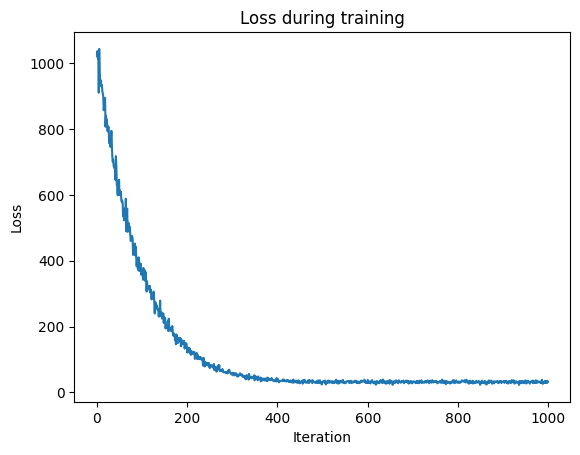

In [4]:
# Huấn luyện và vẽ đồ thị
W, loss_history = multiclass_svm_GD_vectorized(X, y, W, reg)
plt.plot(loss_history)
plt.title("Loss during training")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

# Tự thực hành 1

#### Tạo dữ liệu 2 chiều với phân bố chuẩn và trực quan hóa

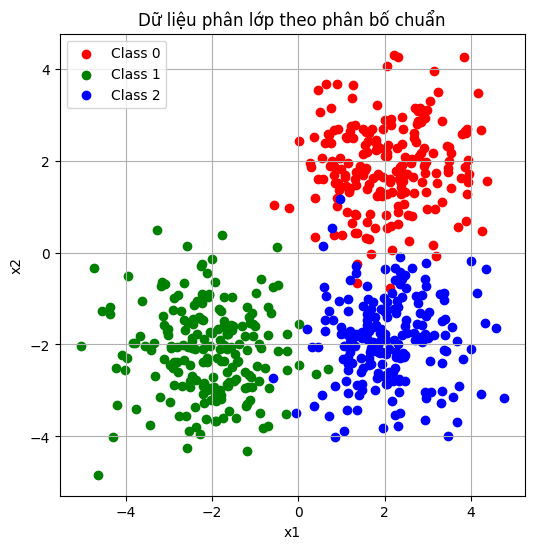

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Tạo dữ liệu 2 chiều cho 3 lớp, mỗi lớp 200 điểm
np.random.seed(0)
N = 200
C = 3
d = 2

X0 = np.random.randn(d, N) + np.array([[2], [2]])
X1 = np.random.randn(d, N) + np.array([[-2], [-2]])
X2 = np.random.randn(d, N) + np.array([[2], [-2]])

X = np.hstack((X0, X1, X2))
y = np.array([0]*N + [1]*N + [2]*N)

# Trực quan hóa dữ liệu
plt.figure(figsize=(6,6))
for i, color in zip(range(C), ['r', 'g', 'b']):
    plt.scatter(X[0, y == i], X[1, y == i], c=color, label=f'Class {i}')
plt.title('Dữ liệu phân lớp theo phân bố chuẩn')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

#### Huấn luyện mô hình SVM với dữ liệu vừa tạo

it 1/300, loss = 0.484227
it 51/300, loss = 0.113639
it 101/300, loss = 0.194531
it 151/300, loss = 0.108431
it 201/300, loss = 0.091533
it 251/300, loss = 0.090787


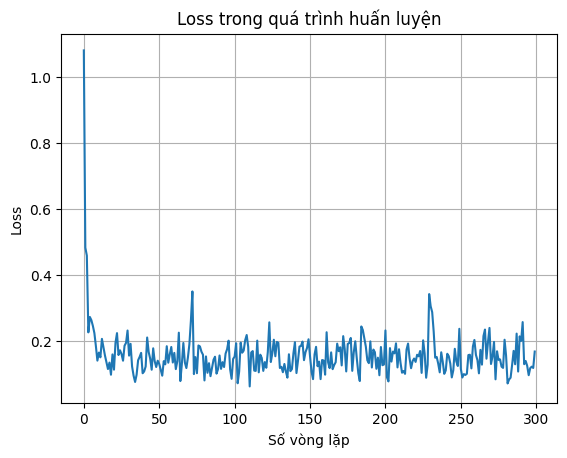

In [6]:
# Khởi tạo tham số và trọng số
Winit = np.random.randn(d, C)
reg = 0.05

# Huấn luyện bằng GD vector hóa
W, loss_history = multiclass_svm_GD_vectorized(X, y, Winit, reg, lr=1.0, batch_size=60, num_iters=300, print_every=50)

# Vẽ loss
plt.plot(loss_history)
plt.title("Loss trong quá trình huấn luyện")
plt.xlabel("Số vòng lặp")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Tự thực hành 2

#### Dự đoán, Tính Accuracy và Ma trận nhầm lẫn


Multi-Class SVM (2D Gaussian Data)
Accuracy: 97.33%


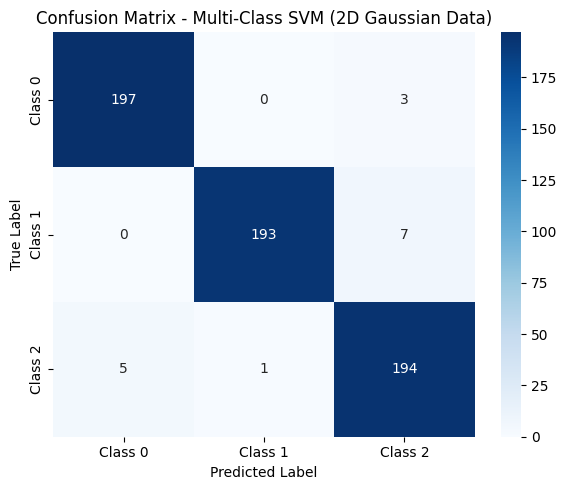

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Hàm dự đoán
def predict(X, W):
    scores = W.T @ X
    return np.argmax(scores, axis=0)

# Hàm đánh giá và vẽ ma trận nhầm lẫn
def evaluate_and_plot(y_true, y_pred, method_name="Multi-Class SVM"):
    acc = accuracy_score(y_true.flatten(), y_pred)
    cm = confusion_matrix(y_true.flatten(), y_pred)

    print(f"\n{method_name}")
    print(f"Accuracy: {acc * 100:.2f}%")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Class {i}' for i in np.unique(y_true)],
                yticklabels=[f'Class {i}' for i in np.unique(y_true)])
    plt.title(f'Confusion Matrix - {method_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# Dự đoán và đánh giá
y_pred = predict(X, W)
evaluate_and_plot(y, y_pred, method_name="Multi-Class SVM (2D Gaussian Data)")

# Ví dụ 2

#### SVM với dữ liệu nhân tạo

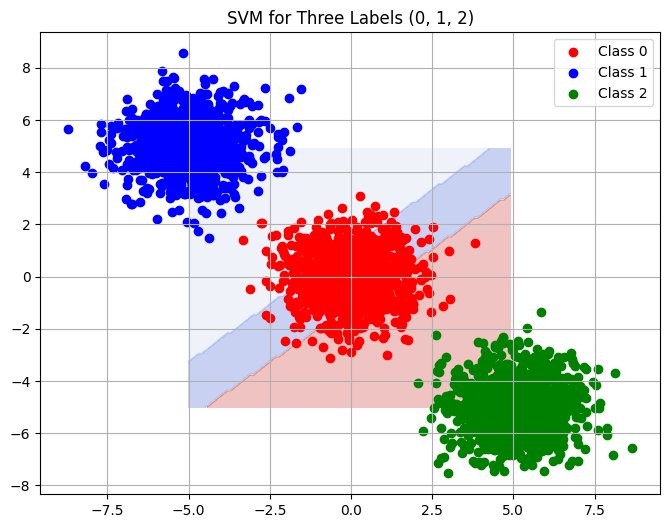

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Số mẫu mỗi lớp
N = 1000

# Sinh dữ liệu giả lập cho 3 lớp
X1 = np.random.normal(loc=0, scale=1, size=(N, 2))
Y1 = np.zeros(N, dtype=int)

X2 = np.random.normal(loc=[-5, 5], scale=1, size=(N, 2))
Y2 = np.ones(N, dtype=int)

X3 = np.random.normal(loc=[5, -5], scale=1, size=(N, 2))
Y3 = np.full(N, 2, dtype=int)

# Kết hợp toàn bộ dữ liệu
X = np.vstack((X1, X2, X3))
Y = np.hstack((Y1, Y2, Y3))

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Huấn luyện mô hình SVM
clf = SVC(kernel='linear')
clf.fit(X_scaled, Y)

# Tạo lưới cho biểu diễn biên quyết định
xx, yy = np.meshgrid(np.arange(-5, 5, 0.1), np.arange(-5, 5, 0.1))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf.predict(grid)
Z = Z.reshape(xx.shape)

# Vẽ dữ liệu và biên phân lớp
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
plt.scatter(X1[:, 0], X1[:, 1], c='r', label='Class 0')
plt.scatter(X2[:, 0], X2[:, 1], c='b', label='Class 1')
plt.scatter(X3[:, 0], X3[:, 1], c='g', label='Class 2')
plt.title("SVM for Three Labels (0, 1, 2)")
plt.legend()
plt.grid(True)
plt.show()

# Bài tập tự thực hành 4:

#### Huấn luyện và dự đoán với tập ảnh chữ số viết tay

Ta sử dụng tập dữ liệu MNIST (handwritten digits) với sklearn.


SVM on MNIST (1000 train / 500 test)
Accuracy: 89.00%


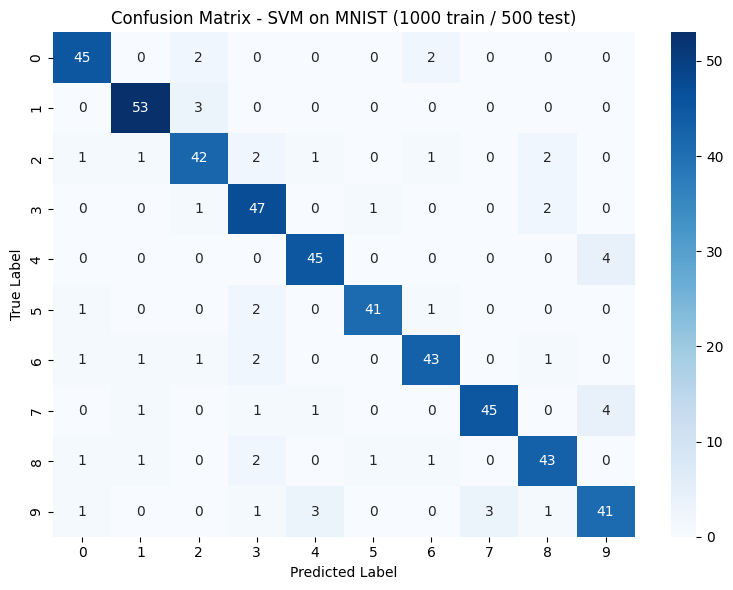

In [9]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Tải dữ liệu chữ số viết tay
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data, mnist.target.astype(int)

# Chọn 1000 ảnh để train, 500 ảnh để test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=1000, test_size=500, stratify=y, random_state=42)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Huấn luyện mô hình SVM
clf = SVC(kernel='linear')
clf.fit(X_train_scaled, y_train)

# Dự đoán
y_pred = clf.predict(X_test_scaled)

# Hàm đánh giá và vẽ ma trận nhầm lẫn
def evaluate_and_plot(y_true, y_pred, method_name="SVM - MNIST"):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{method_name}")
    print(f"Accuracy: {acc * 100:.2f}%")

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[str(i) for i in range(10)],
                yticklabels=[str(i) for i in range(10)])
    plt.title(f'Confusion Matrix - {method_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# Đánh giá mô hình
evaluate_and_plot(y_test, y_pred, method_name="SVM on MNIST (1000 train / 500 test)")